<a href="https://colab.research.google.com/github/idanm-commiting/Sanitation-Project/blob/main/Copy_of_Juan's_Work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

Column A contains the inspection ID numbers. Each ID is unique, so no pattern is apparent.
Column B contains the DBA. Each DBA is unique, so no pattern is apparent.
Column C contains the AKA name. Each AKA name is unique, so no pattern is apparent.


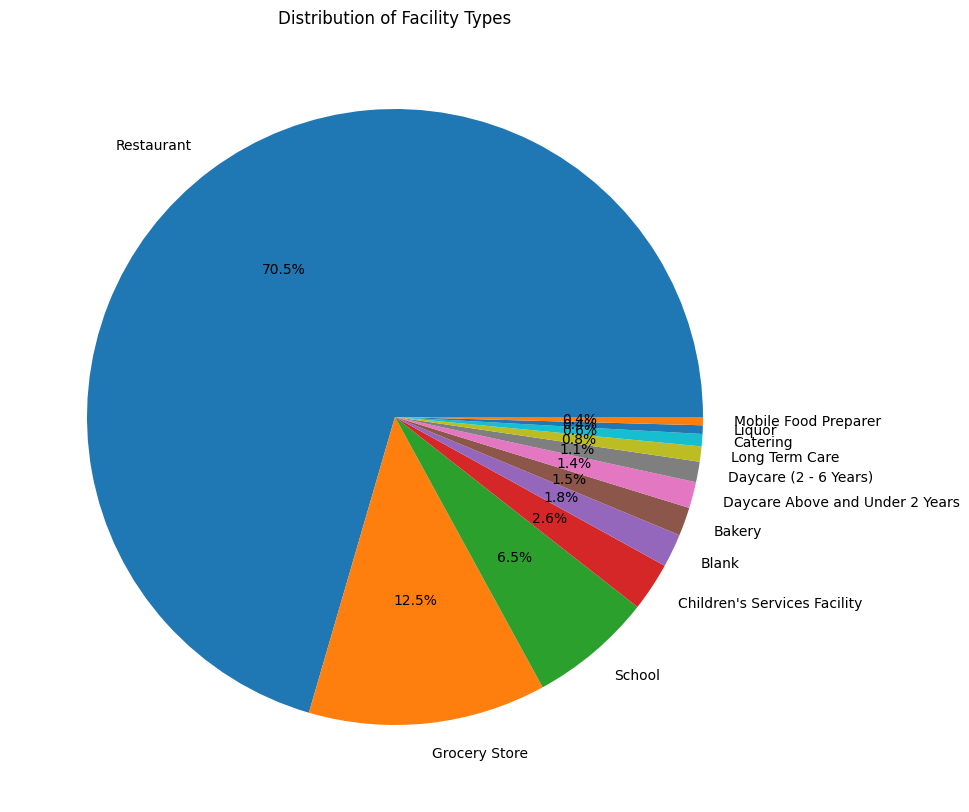

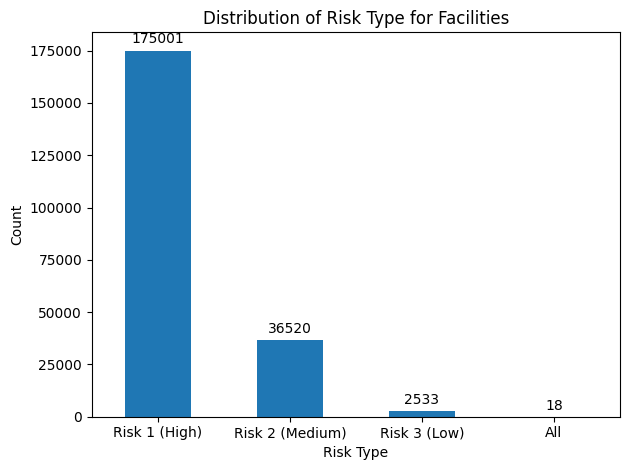

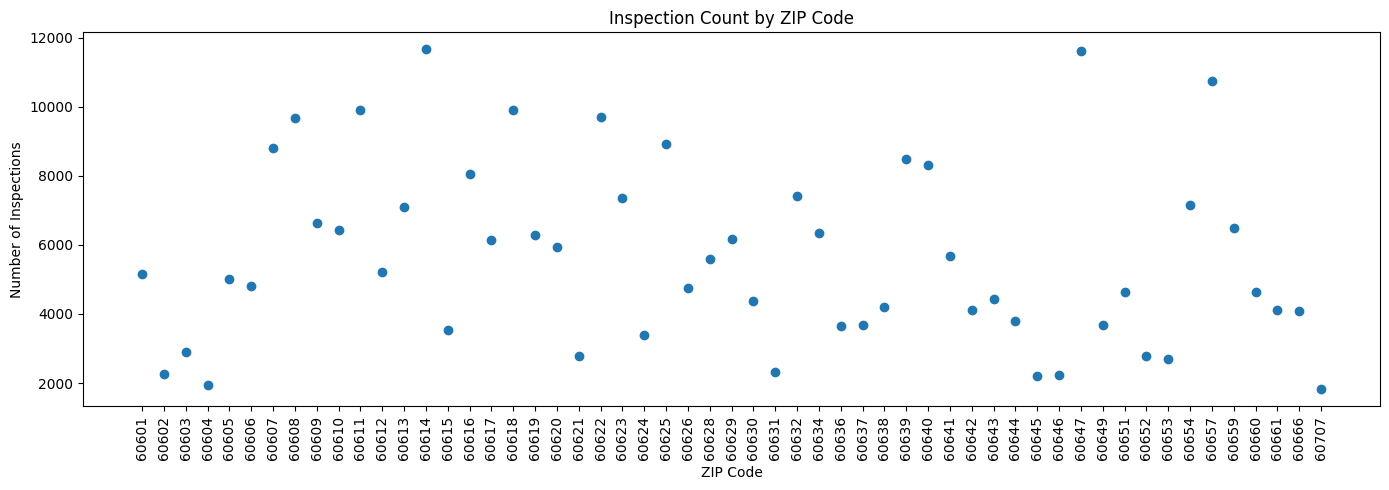

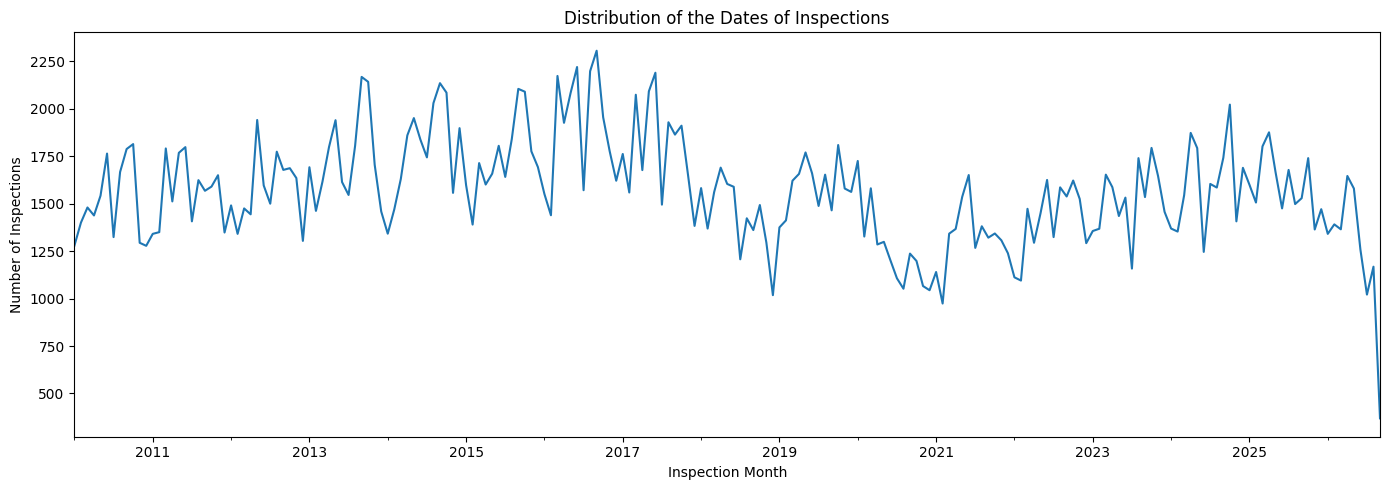

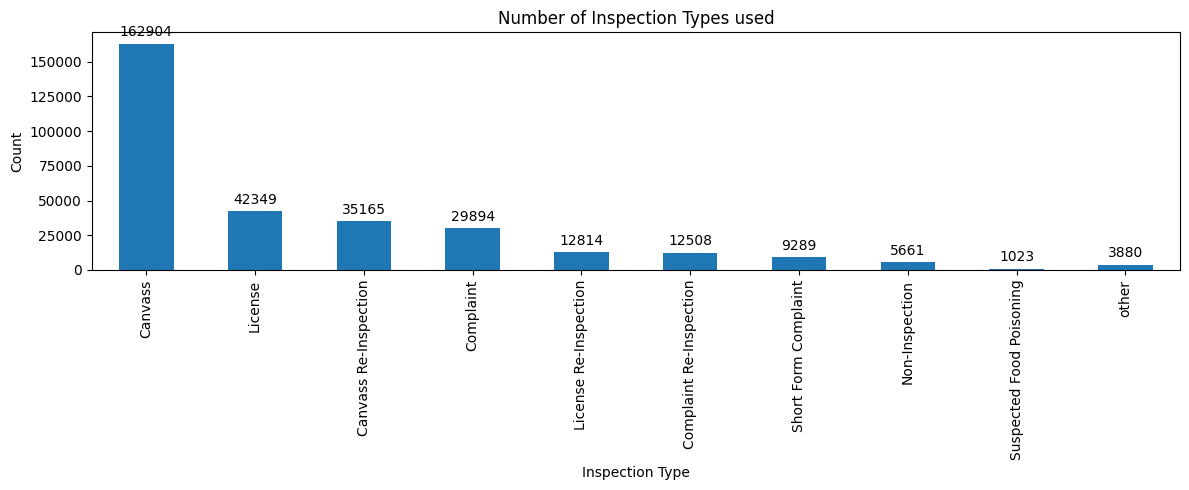

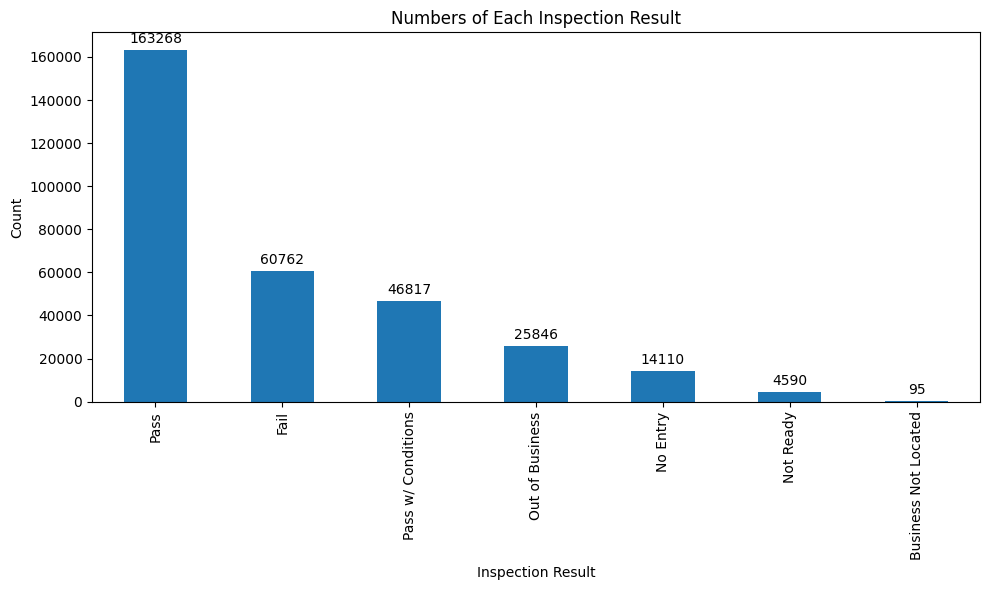

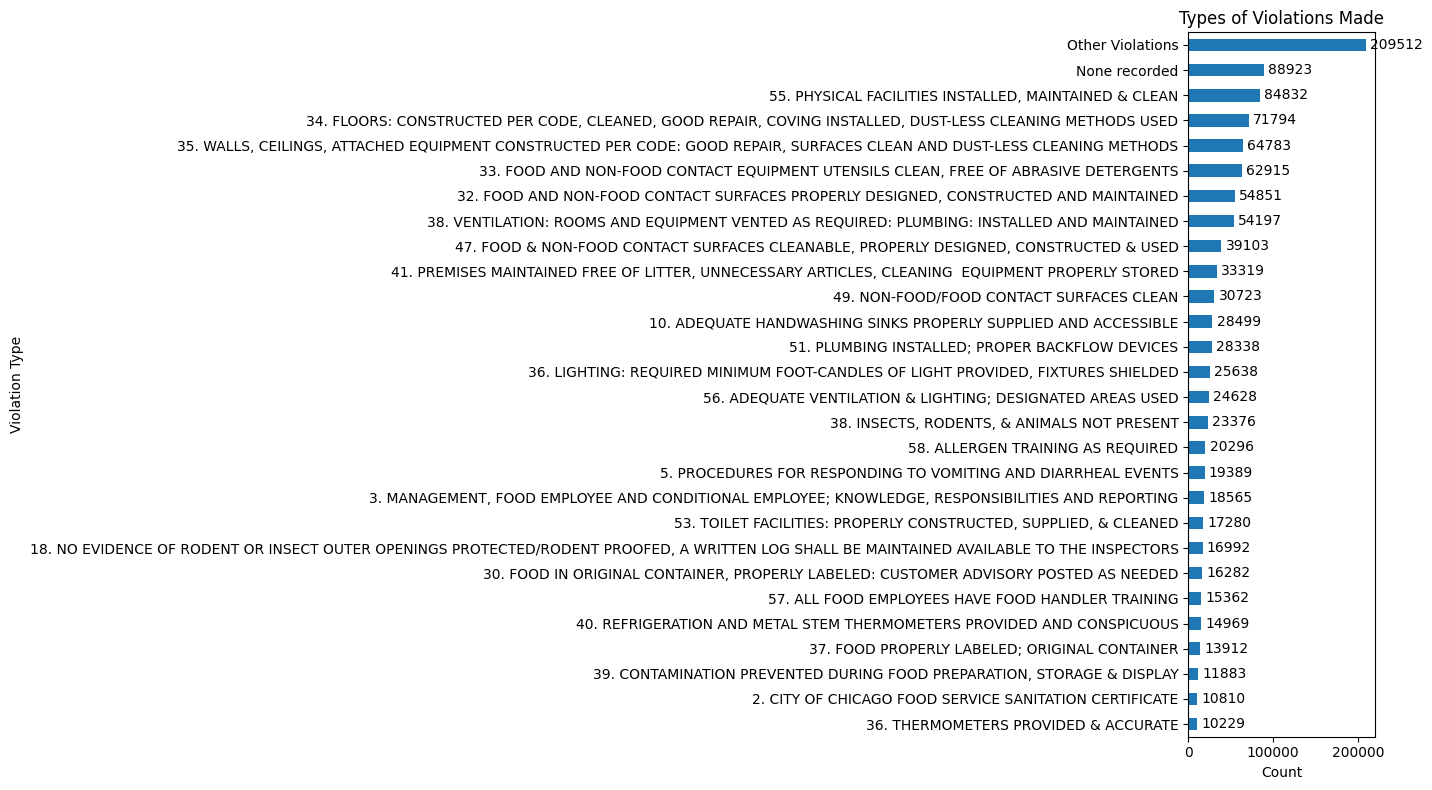

Column D contains the Liscence number. Each the Liscence number is unique, so no pattern is apparent.
Column G contains the address. Each the address is unique, so no pattern is apparent.
Column H contains the city. The city is the same, so no pattern is apparent.
Column I contains the State. The State is the same, so no pattern is apparent.
Latitude, Longitude and locations are all distinct. So no patterns can be attributed to them.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and combine the four inspection files
base_url = "https://raw.githubusercontent.com/idanm-commiting/Sanitation-Project/main/"
parts = ["1", "2a", "2b", "3"]
frames = []

for part in parts:
    filename = f"Food_Inspections_part_{part}.zip"
    frame = pd.read_csv(base_url + filename, compression="zip", low_memory=False)
    frames.append(frame)

DataFrame12 = pd.concat(frames, ignore_index=True)

# Rename columns and convert dates
DataFrame12 = DataFrame12.rename(columns={
    "Address": "Street Address",
    "Zip": "ZIP Code"
})

DataFrame12["Record Date"] = pd.to_datetime(
    DataFrame12["Inspection Date"], errors="coerce", format="mixed"
)

# Clean facility types
DataFrame12["Facility Type"] = DataFrame12["Facility Type"].fillna("Blank")
DataFrame12["Facility Type"] = DataFrame12["Facility Type"].str.strip()
DataFrame12["Facility Type"] = DataFrame12["Facility Type"].replace("", "Blank")

print("Column A contains the inspection ID numbers. Each ID is unique, so no pattern is apparent.")
print("Column B contains the DBA. Each DBA is unique, so no pattern is apparent.")
print("Column C contains the AKA name. Each AKA name is unique, so no pattern is apparent.")

# Facility types
facility_counts = DataFrame12["Facility Type"].value_counts()
facility_counts = facility_counts.loc[facility_counts >= 1000]

plt.figure(figsize=(10, 10))
plt.pie(facility_counts, labels=facility_counts.index, autopct="%1.1f%%")
plt.title("Distribution of Facility Types")
plt.show()

# Restaurant risk types
restaurants = DataFrame12.loc[
    DataFrame12["Facility Type"].str.lower() == "restaurant"
]
risk_counts = restaurants["Risk"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(risk_counts.index, risk_counts.values)
ax.set(
    title="Distribution of Risk Type for Facilities",
    xlabel="Risk Type",
    ylabel="Count"
)
ax.bar_label(bars, padding=3)
plt.tight_layout()
plt.show()

# ZIP codes
zip_codes = DataFrame12["ZIP Code"].dropna().astype(str)
zip_codes = zip_codes.str.replace(r"\.0$", "", regex=True)
zip_counts = zip_codes.value_counts().sort_index()
zip_counts = zip_counts.loc[zip_counts >= 1500]

plt.figure(figsize=(14, 5))
plt.scatter(zip_counts.index, zip_counts.values)
plt.title("Inspection Count by ZIP Code")
plt.xlabel("ZIP Code")
plt.ylabel("Number of Inspections")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Monthly inspections
dated_inspections = DataFrame12.dropna(subset=["Record Date"]).copy()
dated_inspections["Month"] = dated_inspections["Record Date"].dt.to_period("M")
monthly_counts = dated_inspections.groupby("Month").size()
monthly_counts.index = monthly_counts.index.to_timestamp()

plt.figure(figsize=(14, 5))
plt.plot(monthly_counts.index, monthly_counts.values)
plt.title("Distribution of the Dates of Inspections")
plt.xlabel("Inspection Month")
plt.ylabel("Number of Inspections")
plt.tight_layout()
plt.show()

# Inspection types
inspection_counts = DataFrame12["Inspection Type"].value_counts()
shown = inspection_counts.loc[inspection_counts >= 1000].copy()
shown.loc["other"] = inspection_counts.loc[inspection_counts < 1000].sum()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(shown.index, shown.values)
ax.set(
    title="Number of Inspection Types used",
    xlabel="Inspection Type",
    ylabel="Count"
)
ax.bar_label(bars, padding=3)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Inspection results
result_counts = DataFrame12["Results"].fillna("Blank").value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(result_counts.index, result_counts.values)
ax.set(
    title="Numbers of Each Inspection Result",
    xlabel="Inspection Result",
    ylabel="Count"
)
ax.bar_label(bars, padding=3)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Split each inspection's violations into separate entries
violations = DataFrame12["Violations"].fillna("None recorded")
violations = violations.str.strip().replace("", "None recorded")
violations = violations.str.split("|", regex=False).explode()

# Remove inspector comments and count violation types
violations = violations.str.split(" - Comments:", n=1).str[0].str.strip()
violation_counts = violations.value_counts()

small = (violation_counts < 10000) & (violation_counts.index != "None recorded")
shown = violation_counts.loc[~small].copy()
shown.loc["Other Violations"] = violation_counts.loc[small].sum()
shown = shown.sort_values()

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(shown.index, shown.values)
ax.set(
    title="Types of Violations Made",
    xlabel="Count",
    ylabel="Violation Type"
)
ax.bar_label(bars, padding=3)
plt.tight_layout()
plt.show()

print("Column D contains the Liscence number. Each the Liscence number is unique, so no pattern is apparent.")
print("Column G contains the address. Each the address is unique, so no pattern is apparent.")
print("Column H contains the city. The city is the same, so no pattern is apparent.")
print("Column I contains the State. The State is the same, so no pattern is apparent.")
print("Latitude, Longitude and locations are all distinct. So no patterns can be attributed to them.")

In [ ]:
DataFrame12.dtypes

,0
Inspection ID,int64
DBA Name,object
AKA Name,object
License #,float64
Facility Type,object
Risk,object
Address,object
City,object
State,object
Zip,float64


In [ ]:
import pandas as pd

facility = pd.read_csv("/content/summary.csv", header=1, usecols=[2, 3])
display(facility)

FileNotFoundError: [Errno 2] No such file or directory: '/content/summary.csv'

In [ ]:
!find /content -name "summary.csv"

/content/summary.csv
